# DeepSeek-OCR Fine-Tuning Notebook (single experiment, same data + same paths)

This notebook mirrors the structure of `update.ipynb`, but is adapted for **`deepseek-ai/DeepSeek-OCR`** and runs **one fast experiment**.

## What this notebook does
- Uses the same CSV and image paths as your Janus notebook
- Builds the same train/val split from `transcriptions.csv`
- Runs 1 LoRA fine-tuning experiment
- Saves adapter + metadata
- Reports performance with eval loss + OCR text metrics (CER/WER)
- Shows plots for the run

## Notes
- This uses `trust_remote_code=True` for DeepSeek-OCR.
- Training for this model is heavy; keep batch size small.
- If 4-bit load is unstable on your GPU, set `use_4bit=False` in config.

In [1]:
# Colab setup (run once)
%pip -q install -U transformers==4.46.3 datasets accelerate peft bitsandbytes sentencepiece Pillow==9.5.0 opencv-python-headless evaluate jiwer einops addict easydict

In [2]:
import os
import re
import gc
import json
import math
import random
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torchvision import transforms
from datasets import Dataset as HFDataset

from transformers import (
    AutoModel,
    AutoTokenizer,
    BitsAndBytesConfig,
    Trainer,
    TrainingArguments,
    default_data_collator,
)

from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 2))

CUDA available: True
GPU: NVIDIA L4
VRAM (GB): 23.66


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# -------- Config --------
@dataclass
class CFG:
    model_name: str = 'deepseek-ai/DeepSeek-OCR'
    csv_path: str = '/content/transcriptions.csv'
    image_root: str = '/content/drive/MyDrive/data'
    work_dir: str = '/content/drive/MyDrive/brainink_janus_hw'

    min_target_chars: int = 20
    max_target_chars: int = 1200
    max_samples: int | None = None
    val_ratio: float = 0.1

    use_4bit: bool = True
    max_seq_len: int = 2048
    base_size: int = 640
    image_size: int = 640
    crop_mode: bool = False

cfg = CFG()
os.makedirs(cfg.work_dir, exist_ok=True)

PROMPT = '<image>\nFree OCR.'

EXPERIMENTS = [
    {
        'name': 'exp_single_fast',
        'num_train_epochs': 1,
        'learning_rate': 2e-4,
        'gradient_accumulation_steps': 8,
        'lora_r': 32,
        'lora_alpha': 64,
        'lora_dropout': 0.10,
        'per_device_train_batch_size': 1,
        'per_device_eval_batch_size': 1,
        'weight_decay': 0.01,
        'warmup_ratio': 0.03,
    },
]

print('Model:', cfg.model_name)
print('CSV:', cfg.csv_path)
print('Image root:', cfg.image_root)
print('Work dir:', cfg.work_dir)
print('Experiments:', [e['name'] for e in EXPERIMENTS])

Model: deepseek-ai/DeepSeek-OCR
CSV: /content/transcriptions.csv
Image root: /content/drive/MyDrive/data
Work dir: /content/drive/MyDrive/brainink_janus_hw
Experiments: ['exp_single_fast']


In [5]:
# -------- Parse transcription + build reusable dataset (same logic/path behavior) --------
def normalize_space(text: str) -> str:
    text = text.replace('\r', '\n')
    text = re.sub(r'\n+', '\n', text)
    text = re.sub(r'[ \t]+', ' ', text)
    return text.strip()


def extract_printed_target(raw: str) -> str:
    if not isinstance(raw, str):
        return ''

    text = normalize_space(raw)
    lines = [ln.strip() for ln in text.split('\n') if ln.strip()]
    if not lines:
        return ''

    if lines and lines[0].lower().startswith('sentence database'):
        lines = lines[1:]
    if lines and re.match(r'^[A-Za-z]\d{2}-\d{3}', lines[0]):
        lines = lines[1:]

    cut = []
    for ln in lines:
        if ln.lower().startswith('name'):
            break
        cut.append(ln)
    lines = cut
    if not lines:
        return ''

    printed = []
    short_streak = 0
    for ln in lines:
        printed.append(ln)
        if len(ln) < 35:
            short_streak += 1
        else:
            short_streak = 0

        if len(printed) >= 3 and short_streak >= 2:
            printed = printed[:-2]
            break

    if not printed:
        printed = lines[:6]

    label = ' '.join(printed)
    label = re.sub(r'\s+', ' ', label).strip()
    return label


def resolve_input_path(rel_image_path: str) -> str:
    crop_candidate = Path(cfg.work_dir) / 'crops' / rel_image_path
    if crop_candidate.exists():
        return str(crop_candidate)
    return str((Path(cfg.image_root) / rel_image_path).resolve())


df = pd.read_csv(cfg.csv_path)
df['image_path'] = df['image_path'].astype(str).str.strip()
df['target_text'] = df['transcription'].apply(extract_printed_target)

df = df[df['target_text'].str.len() >= cfg.min_target_chars].copy()
df = df[df['target_text'].str.len() <= cfg.max_target_chars].copy()

df['input_path'] = df['image_path'].apply(resolve_input_path)
df = df[df['input_path'].apply(lambda p: Path(p).exists())].copy()

if cfg.max_samples is not None:
    df = df.sample(n=min(cfg.max_samples, len(df)), random_state=SEED).reset_index(drop=True)

df = df.reset_index(drop=True)
print('Usable rows:', len(df))
print('Rows using existing crops:', int(df['image_path'].apply(lambda p: (Path(cfg.work_dir) / 'crops' / p).exists()).sum()))
display(df[['image_path', 'input_path', 'target_text']].head(5))

idx = np.arange(len(df))
rng = np.random.default_rng(SEED)
rng.shuffle(idx)
val_size = max(1, int(len(df) * cfg.val_ratio))
val_idx = idx[:val_size]
train_idx = idx[val_size:]

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

print('Train size:', len(train_df))
print('Val size:', len(val_df))

Usable rows: 1520
Rows using existing crops: 1520


,image_path,input_path,target_text
0,000/a01-000u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,A MOVE to stop Mr. Gaitskell from nominating a...
1,000/a01-003u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Though they may gather some Left-wing support,..."
2,000/a01-007u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,"Since 1958, 13 Labour life Peers and Peeresses..."
3,000/a01-011u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,Delegates from Mr. Kenneth Kaunda's United Nat...
4,000/a01-014u.png,/content/drive/MyDrive/brainink_janus_hw/crops...,Sir Roy's United Federal Party is boycotting t...


Train size: 1368
Val size: 152


## DeepSeek-OCR helpers
This section builds image+token training samples compatible with DeepSeek-OCR custom forward arguments (`images`, `images_seq_mask`, `images_spatial_crop`).

In [6]:
# -------- DeepSeek-OCR reusable model/training helpers --------
from jiwer import wer, cer

IMAGE_TOKEN = '<image>'
IMAGE_TOKEN_ID = 128815


class OCRDataset(torch.utils.data.Dataset):
    def __init__(self, df_in: pd.DataFrame):
        self.df = df_in.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return {
            'input_path': str(row['input_path']),
            'target_text': str(row['target_text']),
        }


def build_bnb_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_compute_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    )


def load_base_components(model_name: str, use_4bit: bool = True):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    load_kwargs = dict(
        trust_remote_code=True,
        use_safetensors=True,
    )

    if torch.cuda.is_available():
        load_kwargs['_attn_implementation'] = 'flash_attention_2'
    if use_4bit and torch.cuda.is_available():
        load_kwargs['quantization_config'] = build_bnb_config()
        load_kwargs['device_map'] = 'auto'
    else:
        load_kwargs['device_map'] = 'auto' if torch.cuda.is_available() else None

    model = AutoModel.from_pretrained(model_name, **load_kwargs)
    model.config.use_cache = False
    return tokenizer, model


def find_lora_targets(model) -> list[str]:
    preferred = {'q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'}
    found = sorted({
        name.split('.')[-1]
        for name, module in model.named_modules()
        if hasattr(module, 'weight') and name.split('.')[-1] in preferred
    })
    if not found:
        raise RuntimeError('No LoRA target modules found in DeepSeek-OCR model.')
    return found


def add_lora(model, lora_r: int, lora_alpha: int, lora_dropout: float):
    if getattr(model, 'is_loaded_in_4bit', False):
        model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=False)

    target_modules = find_lora_targets(model)
    lora_cfg = LoraConfig(
        r=lora_r,
        lora_alpha=lora_alpha,
        lora_dropout=lora_dropout,
        bias='none',
        task_type='CAUSAL_LM',
        target_modules=target_modules,
    )
    model = get_peft_model(model, lora_cfg)
    model.print_trainable_parameters()
    return model


def _build_image_tensors(image_path: str, image_size: int, base_size: int):
    image = Image.open(image_path).convert('RGB')

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ])

    global_view = ImageOps.pad(image, (image_size, image_size), color=(127, 127, 127))
    image_ori = transform(global_view).unsqueeze(0)

    image_crop = torch.zeros((1, 3, base_size, base_size), dtype=image_ori.dtype)
    images_spatial_crop = torch.tensor([[1, 1]], dtype=torch.long)
    return image_crop, image_ori, images_spatial_crop


def _build_sample(tokenizer, sample: dict, prompt: str, image_size: int, base_size: int):
    if IMAGE_TOKEN not in prompt:
        raise ValueError(f'Prompt must include {IMAGE_TOKEN} for DeepSeek-OCR training.')

    text_before, text_after = prompt.split(IMAGE_TOKEN, 1)
    user_prefix = '<|User|>\n'
    assistant_prefix = '\n<|Assistant|>\n'

    before_ids = tokenizer.encode(user_prefix + text_before, add_special_tokens=False)
    after_ids = tokenizer.encode(text_after + assistant_prefix, add_special_tokens=False)
    answer_ids = tokenizer.encode(sample['target_text'], add_special_tokens=False) + [tokenizer.eos_token_id]

    patch = 16
    downsample = 4
    num_queries = math.ceil((image_size // patch) / downsample)
    image_tokens = ([IMAGE_TOKEN_ID] * num_queries + [IMAGE_TOKEN_ID]) * num_queries
    image_tokens += [IMAGE_TOKEN_ID]

    bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else 0

    input_ids = [bos_id] + before_ids + image_tokens + after_ids + answer_ids
    attention_mask = [1] * len(input_ids)
    images_seq_mask = [False] * (1 + len(before_ids)) + [True] * len(image_tokens) + [False] * (len(after_ids) + len(answer_ids))

    prompt_end = 1 + len(before_ids) + len(image_tokens) + len(after_ids)
    labels = input_ids.copy()
    labels[:prompt_end] = [-100] * prompt_end

    image_crop, image_ori, images_spatial_crop = _build_image_tensors(sample['input_path'], image_size=image_size, base_size=base_size)

    return {
        'input_ids': torch.tensor(input_ids, dtype=torch.long),
        'attention_mask': torch.tensor(attention_mask, dtype=torch.long),
        'labels': torch.tensor(labels, dtype=torch.long),
        'images_seq_mask': torch.tensor(images_seq_mask, dtype=torch.bool),
        'images': (image_crop, image_ori),
        'images_spatial_crop': images_spatial_crop,
    }


def collate_deepseek_ocr(batch: list[dict], tokenizer, prompt: str, image_size: int, base_size: int):
    samples = [_build_sample(tokenizer, b, prompt=prompt, image_size=image_size, base_size=base_size) for b in batch]

    pad_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    max_len = max(s['input_ids'].shape[0] for s in samples)

    def _pad_tensor(t: torch.Tensor, pad_value, dtype=None):
        if t.shape[0] == max_len:
            return t
        out = torch.full((max_len,), pad_value, dtype=dtype or t.dtype)
        out[: t.shape[0]] = t
        return out

    input_ids = torch.stack([_pad_tensor(s['input_ids'], pad_id, torch.long) for s in samples], dim=0)
    attention_mask = torch.stack([_pad_tensor(s['attention_mask'], 0, torch.long) for s in samples], dim=0)
    labels = torch.stack([_pad_tensor(s['labels'], -100, torch.long) for s in samples], dim=0)
    images_seq_mask = torch.stack([_pad_tensor(s['images_seq_mask'], False, torch.bool) for s in samples], dim=0)

    images = [s['images'] for s in samples]
    images_spatial_crop = torch.cat([s['images_spatial_crop'] for s in samples], dim=0)

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
        'images_seq_mask': images_seq_mask,
        'images': images,
        'images_spatial_crop': images_spatial_crop,
    }


class DeepSeekOCRTrainerWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.mm_model = model

    @property
    def config(self):
        return self.mm_model.config

    @property
    def device(self):
        return next(self.mm_model.parameters()).device

    def forward(self, **kwargs):
        images = kwargs.pop('images', None)
        if images is not None:
            vision_dtype = torch.bfloat16 if torch.cuda.is_available() else torch.float32
            moved_images = []
            for crop, ori in images:
                moved_images.append((crop.to(self.device, dtype=vision_dtype), ori.to(self.device, dtype=vision_dtype)))
            kwargs['images'] = moved_images

        if 'images_spatial_crop' in kwargs:
            kwargs['images_spatial_crop'] = kwargs['images_spatial_crop'].to(self.device)
        if 'images_seq_mask' in kwargs:
            kwargs['images_seq_mask'] = kwargs['images_seq_mask'].to(self.device)
        if 'input_ids' in kwargs:
            kwargs['input_ids'] = kwargs['input_ids'].to(self.device)
        if 'attention_mask' in kwargs:
            kwargs['attention_mask'] = kwargs['attention_mask'].to(self.device)
        if 'labels' in kwargs:
            kwargs['labels'] = kwargs['labels'].to(self.device)

        return self.mm_model(**kwargs)


def summarize_log_history(trainer):
    logs = pd.DataFrame(getattr(trainer.state, 'log_history', []) or [])
    if logs.empty:
        return {'best_eval_loss': None, 'last_train_loss': None, 'last_learning_rate': None}

    best_eval_loss = None
    if 'eval_loss' in logs.columns:
        eval_vals = pd.to_numeric(logs['eval_loss'], errors='coerce').dropna()
        if not eval_vals.empty:
            best_eval_loss = float(eval_vals.min())

    last_train_loss = None
    if 'loss' in logs.columns:
        loss_vals = pd.to_numeric(logs['loss'], errors='coerce').dropna()
        if not loss_vals.empty:
            last_train_loss = float(loss_vals.iloc[-1])

    last_learning_rate = None
    if 'learning_rate' in logs.columns:
        lr_vals = pd.to_numeric(logs['learning_rate'], errors='coerce').dropna()
        if not lr_vals.empty:
            last_learning_rate = float(lr_vals.iloc[-1])

    return {
        'best_eval_loss': best_eval_loss,
        'last_train_loss': last_train_loss,
        'last_learning_rate': last_learning_rate,
    }


def run_eval_samples(base_model, tokenizer, eval_df: pd.DataFrame, sample_n: int = 20):
    use_df = eval_df.sample(n=min(sample_n, len(eval_df)), random_state=SEED).reset_index(drop=True)
    refs, preds = [], []
    tmp_out = Path(cfg.work_dir) / 'tmp_deepseek_eval'
    tmp_out.mkdir(parents=True, exist_ok=True)

    for _, row in use_df.iterrows():
        ref = str(row['target_text'])
        img = str(row['input_path'])
        pred = ''
        try:
            pred = base_model.infer(
                tokenizer,
                prompt=PROMPT,
                image_file=img,
                output_path=str(tmp_out),
                base_size=cfg.base_size,
                image_size=cfg.image_size,
                crop_mode=cfg.crop_mode,
                eval_mode=True,
            )
        except Exception as err:
            print('Eval sample failed:', err)
            pred = ''
        refs.append(ref)
        preds.append(pred.strip())

    return {
        'subset_size': int(len(use_df)),
        'wer': float(wer(refs, preds)) if len(use_df) > 0 else None,
        'cer': float(cer(refs, preds)) if len(use_df) > 0 else None,
    }


def train_one_experiment(exp: dict):
    exp_name = exp['name']
    print('\n' + '=' * 100)
    print('Starting experiment:', exp_name)

    tokenizer, base_model = load_base_components(cfg.model_name, use_4bit=cfg.use_4bit)
    base_model = add_lora(base_model, exp['lora_r'], exp['lora_alpha'], exp['lora_dropout'])
    model = DeepSeekOCRTrainerWrapper(base_model)

    train_ds = OCRDataset(train_df[['input_path', 'target_text']])
    val_ds = OCRDataset(val_df[['input_path', 'target_text']])

    output_dir = Path(cfg.work_dir) / 'checkpoints' / exp_name
    adapter_dir = Path(cfg.work_dir) / 'deepseek_ocr_adapter' / exp_name
    output_dir.mkdir(parents=True, exist_ok=True)
    adapter_dir.mkdir(parents=True, exist_ok=True)

    train_args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=exp['num_train_epochs'],
        per_device_train_batch_size=exp['per_device_train_batch_size'],
        per_device_eval_batch_size=exp['per_device_eval_batch_size'],
        gradient_accumulation_steps=exp['gradient_accumulation_steps'],
        learning_rate=exp['learning_rate'],
        weight_decay=exp['weight_decay'],
        warmup_ratio=exp['warmup_ratio'],
        logging_steps=10,
        eval_strategy='steps',
        eval_steps=100,
        save_strategy='steps',
        save_steps=100,
        save_total_limit=2,
        bf16=torch.cuda.is_available(),
        fp16=False,
        dataloader_num_workers=0,
        remove_unused_columns=False,
        report_to='none',
        overwrite_output_dir=True,
    )

    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=lambda b: collate_deepseek_ocr(b, tokenizer, PROMPT, cfg.image_size, cfg.base_size),
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    log_summary = summarize_log_history(trainer)

    trained_mm = trainer.model.mm_model if hasattr(trainer.model, 'mm_model') else trainer.model
    trained_mm.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    eval_text_metrics = run_eval_samples(trained_mm.eval(), tokenizer, val_df, sample_n=20)

    meta = {
        'experiment': exp_name,
        'model_name': cfg.model_name,
        'train_size': int(len(train_df)),
        'val_size': int(len(val_df)),
        'prompt': PROMPT,
        'hyperparameters': exp,
        'eval_metrics': eval_metrics,
        'log_summary': log_summary,
        'text_metrics': eval_text_metrics,
    }
    with open(adapter_dir / 'training_meta.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    result = {
        'experiment': exp_name,
        'adapter_dir': str(adapter_dir),
        'checkpoint_dir': str(output_dir),
        'eval_loss': float(eval_metrics['eval_loss']) if 'eval_loss' in eval_metrics else None,
        'best_eval_loss': log_summary['best_eval_loss'],
        'last_train_loss': log_summary['last_train_loss'],
        'last_learning_rate': log_summary['last_learning_rate'],
        'wer': eval_text_metrics['wer'],
        'cer': eval_text_metrics['cer'],
    }
    result.update({f'hp_{k}': v for k, v in exp.items() if k != 'name'})

    del trainer
    del model
    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Finished experiment:', exp_name)
    print('Result:', result)
    return result

In [7]:
# -------- FlashAttention-safe loader patch (run once before training cell) --------
import importlib.util

def _has_flash_attn() -> bool:
    return importlib.util.find_spec('flash_attn') is not None

def load_base_components(model_name: str, use_4bit: bool = True):
    tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token

    load_kwargs = dict(
        trust_remote_code=True,
        use_safetensors=True,
    )

    if torch.cuda.is_available() and _has_flash_attn():
        load_kwargs['_attn_implementation'] = 'flash_attention_2'
        print('Attention backend: flash_attention_2')
    else:
        # DeepSeek-OCR custom model path does not support SDPA in this stack.
        load_kwargs['_attn_implementation'] = 'eager'
        if torch.cuda.is_available():
            print('Attention backend: eager (flash_attn not installed)')
        else:
            print('Attention backend: eager (CPU)')

    if use_4bit and torch.cuda.is_available():
        load_kwargs['quantization_config'] = build_bnb_config()
        load_kwargs['device_map'] = 'auto'
    else:
        load_kwargs['device_map'] = 'auto' if torch.cuda.is_available() else None

    model = AutoModel.from_pretrained(model_name, **load_kwargs)
    model.config.use_cache = False
    return tokenizer, model

In [8]:
# -------- FP16 stability patch for DeepSeek-OCR training (run once before training cell) --------
class DeepSeekOCRTrainerWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.mm_model = model

    @property
    def config(self):
        return self.mm_model.config

    @property
    def device(self):
        return next(self.mm_model.parameters()).device

    def forward(self, **kwargs):
        images = kwargs.pop('images', None)
        if images is not None:
            vision_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
            moved_images = []
            for crop, ori in images:
                moved_images.append((crop.to(self.device, dtype=vision_dtype), ori.to(self.device, dtype=vision_dtype)))
            kwargs['images'] = moved_images

        if 'images_spatial_crop' in kwargs:
            kwargs['images_spatial_crop'] = kwargs['images_spatial_crop'].to(self.device)
        if 'images_seq_mask' in kwargs:
            kwargs['images_seq_mask'] = kwargs['images_seq_mask'].to(self.device)
        if 'input_ids' in kwargs:
            kwargs['input_ids'] = kwargs['input_ids'].to(self.device)
        if 'attention_mask' in kwargs:
            kwargs['attention_mask'] = kwargs['attention_mask'].to(self.device)
        if 'labels' in kwargs:
            kwargs['labels'] = kwargs['labels'].to(self.device)

        return self.mm_model(**kwargs)


def train_one_experiment(exp: dict):
    exp_name = exp['name']
    print('\n' + '=' * 100)
    print('Starting experiment:', exp_name)

    tokenizer, base_model = load_base_components(cfg.model_name, use_4bit=cfg.use_4bit)
    base_model = add_lora(base_model, exp['lora_r'], exp['lora_alpha'], exp['lora_dropout'])
    model = DeepSeekOCRTrainerWrapper(base_model)

    train_ds = OCRDataset(train_df[['input_path', 'target_text']])
    val_ds = OCRDataset(val_df[['input_path', 'target_text']])

    output_dir = Path(cfg.work_dir) / 'checkpoints' / exp_name
    adapter_dir = Path(cfg.work_dir) / 'deepseek_ocr_adapter' / exp_name
    output_dir.mkdir(parents=True, exist_ok=True)
    adapter_dir.mkdir(parents=True, exist_ok=True)

    train_args = TrainingArguments(
        output_dir=str(output_dir),
        num_train_epochs=exp['num_train_epochs'],
        per_device_train_batch_size=exp['per_device_train_batch_size'],
        per_device_eval_batch_size=exp['per_device_eval_batch_size'],
        gradient_accumulation_steps=exp['gradient_accumulation_steps'],
        learning_rate=exp['learning_rate'],
        weight_decay=exp['weight_decay'],
        warmup_ratio=exp['warmup_ratio'],
        logging_steps=10,
        eval_strategy='steps',
        eval_steps=100,
        save_strategy='steps',
        save_steps=100,
        save_total_limit=2,
        bf16=False,
        fp16=torch.cuda.is_available(),
        dataloader_num_workers=0,
        remove_unused_columns=False,
        report_to='none',
        overwrite_output_dir=True,
    )

    trainer = Trainer(
        model=model,
        args=train_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        data_collator=lambda b: collate_deepseek_ocr(b, tokenizer, PROMPT, cfg.image_size, cfg.base_size),
    )

    trainer.train()
    eval_metrics = trainer.evaluate()
    log_summary = summarize_log_history(trainer)

    trained_mm = trainer.model.mm_model if hasattr(trainer.model, 'mm_model') else trainer.model
    trained_mm.save_pretrained(adapter_dir)
    tokenizer.save_pretrained(adapter_dir)

    eval_text_metrics = run_eval_samples(trained_mm.eval(), tokenizer, val_df, sample_n=20)

    meta = {
        'experiment': exp_name,
        'model_name': cfg.model_name,
        'train_size': int(len(train_df)),
        'val_size': int(len(val_df)),
        'prompt': PROMPT,
        'hyperparameters': exp,
        'eval_metrics': eval_metrics,
        'log_summary': log_summary,
        'text_metrics': eval_text_metrics,
    }
    with open(adapter_dir / 'training_meta.json', 'w', encoding='utf-8') as f:
        json.dump(meta, f, indent=2)

    result = {
        'experiment': exp_name,
        'adapter_dir': str(adapter_dir),
        'checkpoint_dir': str(output_dir),
        'eval_loss': float(eval_metrics['eval_loss']) if 'eval_loss' in eval_metrics else None,
        'best_eval_loss': log_summary['best_eval_loss'],
        'last_train_loss': log_summary['last_train_loss'],
        'last_learning_rate': log_summary['last_learning_rate'],
        'wer': eval_text_metrics['wer'],
        'cer': eval_text_metrics['cer'],
    }
    result.update({f'hp_{k}': v for k, v in exp.items() if k != 'name'})

    del trainer
    del model
    del base_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print('Finished experiment:', exp_name)
    print('Result:', result)
    return result

In [9]:
# -------- Causal mask overflow patch (run once before training cell) --------
from transformers.modeling_attn_mask_utils import AttentionMaskConverter

_orig_make_causal_mask = AttentionMaskConverter._make_causal_mask

def _patched_make_causal_mask(input_ids_shape, dtype, device, past_key_values_length=0, sliding_window=None):
    try:
        return _orig_make_causal_mask(
            input_ids_shape=input_ids_shape,
            dtype=dtype,
            device=device,
            past_key_values_length=past_key_values_length,
            sliding_window=sliding_window,
        )
    except RuntimeError as err:
        if 'cannot be converted to type c10::Half without overflow' not in str(err):
            raise
        safe_dtype = torch.float16 if torch.cuda.is_available() else torch.float32
        mask = _orig_make_causal_mask(
            input_ids_shape=input_ids_shape,
            dtype=safe_dtype,
            device=device,
            past_key_values_length=past_key_values_length,
            sliding_window=sliding_window,
        )
        return mask.to(dtype)

AttentionMaskConverter._make_causal_mask = staticmethod(_patched_make_causal_mask)
print('Applied causal-mask overflow patch.')

Applied causal-mask overflow patch.


In [10]:
# -------- Optional: silence repetitive DeepSeek-OCR debug prints --------
import builtins
import sys

def _fallback_print(*args, sep=' ', end='\n', file=None, flush=False, **kwargs):
    stream = file if file is not None else sys.__stdout__
    stream.write(sep.join(str(a) for a in args) + end)
    if flush:
        stream.flush()

saved = getattr(builtins, '_brainink_orig_print', None)
if saved is None or getattr(saved, '__name__', '') == '_quiet_print':
    builtins._brainink_orig_print = _fallback_print

_orig_print = builtins._brainink_orig_print

def _quiet_print(*args, **kwargs):
    msg = ' '.join(str(a) for a in args).strip()
    blocked = {
        '=====================',
        'NO PATCHES',
    }
    if msg in blocked:
        return
    if msg.startswith('BASE:') and 'torch.Size' in msg:
        return
    _orig_print(*args, **kwargs)

if builtins.print is not _quiet_print:
    builtins.print = _quiet_print

_orig_print('Applied quiet logging patch (suppressed BASE/NO PATCHES spam).')

In [11]:
# -------- Run single experiment --------
all_results = []

for exp in EXPERIMENTS:
    res = train_one_experiment(exp)
    all_results.append(res)

results_df = pd.DataFrame(all_results)
print('\nCompleted runs:', len(results_df))
display(results_df)

if 'best_eval_loss' in results_df.columns and results_df['best_eval_loss'].notna().any():
    best_row = results_df.sort_values('best_eval_loss', ascending=True).iloc[0]
elif 'eval_loss' in results_df.columns and results_df['eval_loss'].notna().any():
    best_row = results_df.sort_values('eval_loss', ascending=True).iloc[0]
else:
    best_row = None

if best_row is not None:
    print('\nRun name:', best_row['experiment'])
    print('Eval loss:', best_row.get('best_eval_loss', best_row.get('eval_loss', None)))
    if 'cer' in best_row and pd.notna(best_row['cer']):
        print('CER:', best_row['cer'])
    if 'wer' in best_row and pd.notna(best_row['wer']):
        print('WER:', best_row['wer'])

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
The attention layers in this model are transitioning from computing the RoPE embeddings internally through `position_ids` (2D tensor with the indexes of the tokens), to using externally computed `position_embeddings` (Tuple of tensors, containing cos and sin). In v4.46 `position_ids` will be removed and `position_embeddings` will be mandatory.


Step,Training Loss,Validation Loss
100,0.533100,No log


Step,Training Loss,Validation Loss
100,0.533100,No log


You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:590: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:None for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
The `seen_tokens` attribute is deprecated and w

,experiment,adapter_dir,checkpoint_dir,eval_loss,best_eval_loss,last_train_loss,last_learning_rate,wer,cer,hp_num_train_epochs,hp_learning_rate,hp_gradient_accumulation_steps,hp_lora_r,hp_lora_alpha,hp_lora_dropout,hp_per_device_train_batch_size,hp_per_device_eval_batch_size,hp_weight_decay,hp_warmup_ratio
0,exp_single_fast,/content/drive/MyDrive/brainink_janus_hw/deeps...,/content/drive/MyDrive/brainink_janus_hw/check...,None,None,0.4609,0.000002,0.467875,0.414775,1,0.0002,8,32,64,0.1,1,1,0.01,0.03


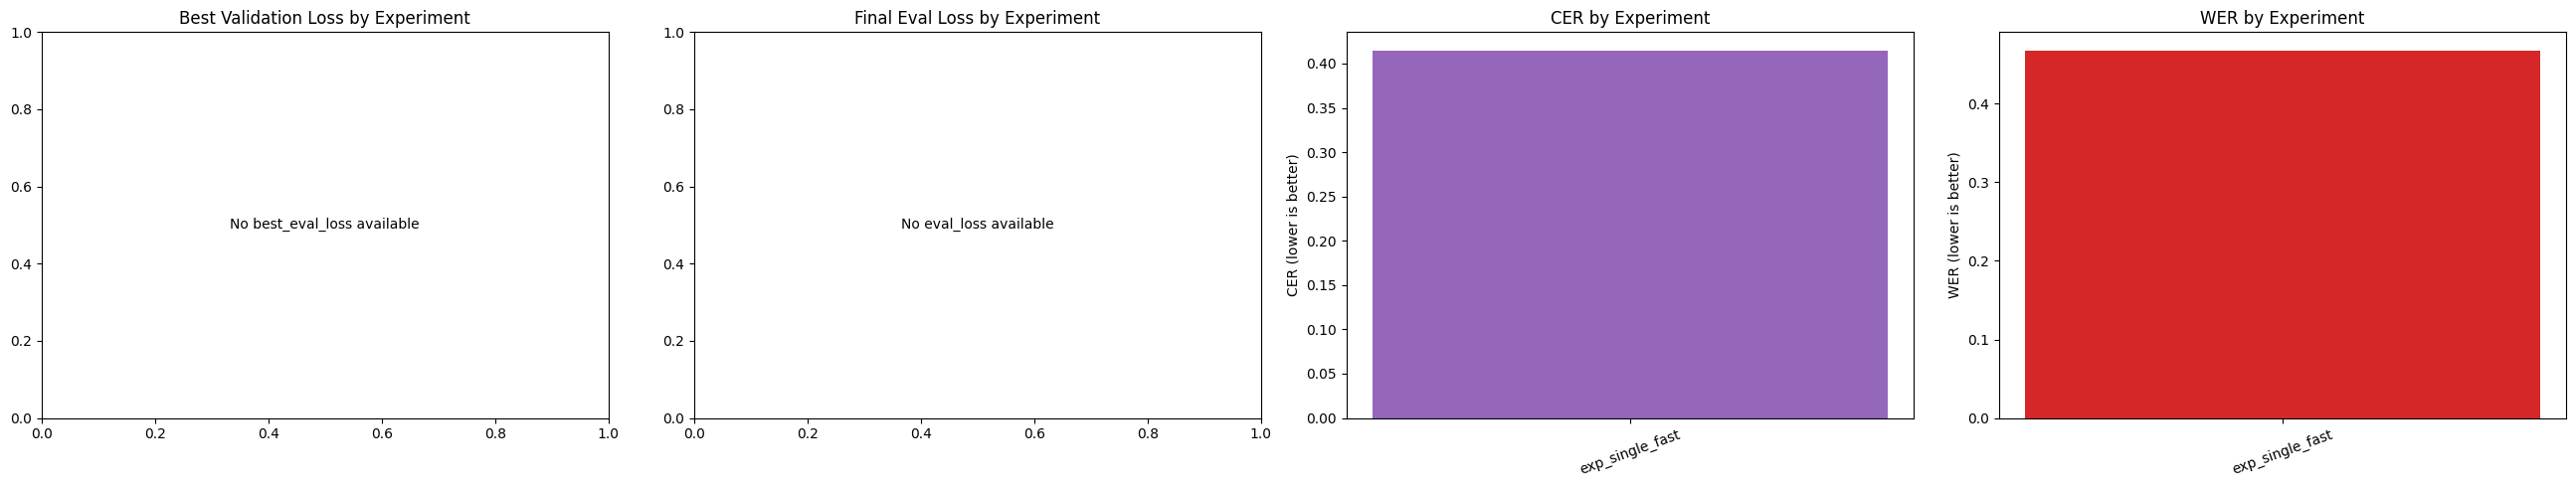

,rank,experiment,adapter_dir,checkpoint_dir,eval_loss,best_eval_loss,last_train_loss,last_learning_rate,wer,cer,hp_num_train_epochs,hp_learning_rate,hp_gradient_accumulation_steps,hp_lora_r,hp_lora_alpha,hp_lora_dropout,hp_per_device_train_batch_size,hp_per_device_eval_batch_size,hp_weight_decay,hp_warmup_ratio
0,1,exp_single_fast,/content/drive/MyDrive/brainink_janus_hw/deeps...,/content/drive/MyDrive/brainink_janus_hw/check...,None,None,0.4609,0.000002,0.467875,0.414775,1,0.0002,8,32,64,0.1,1,1,0.01,0.03


In [12]:
# -------- Comparison plots (loss + text metrics) --------
import matplotlib.pyplot as plt

if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No experiment results found. Run the previous cell first.')
else:
    plot_df = results_df.copy()

    fig, axes = plt.subplots(1, 4, figsize=(26, 5))

    # 1) Best eval loss
    if 'best_eval_loss' in plot_df.columns and plot_df['best_eval_loss'].notna().any():
        axes[0].bar(plot_df['experiment'], plot_df['best_eval_loss'])
        axes[0].set_title('Best Validation Loss by Experiment')
        axes[0].set_ylabel('Loss (lower is better)')
        axes[0].tick_params(axis='x', rotation=20)
    else:
        axes[0].text(0.5, 0.5, 'No best_eval_loss available', ha='center', va='center')
        axes[0].set_title('Best Validation Loss by Experiment')

    # 2) Final eval loss
    if 'eval_loss' in plot_df.columns and plot_df['eval_loss'].notna().any():
        axes[1].bar(plot_df['experiment'], plot_df['eval_loss'], color='tab:orange')
        axes[1].set_title('Final Eval Loss by Experiment')
        axes[1].set_ylabel('Loss (lower is better)')
        axes[1].tick_params(axis='x', rotation=20)
    else:
        axes[1].text(0.5, 0.5, 'No eval_loss available', ha='center', va='center')
        axes[1].set_title('Final Eval Loss by Experiment')

    # 3) CER
    if 'cer' in plot_df.columns and plot_df['cer'].notna().any():
        axes[2].bar(plot_df['experiment'], plot_df['cer'], color='tab:purple')
        axes[2].set_title('CER by Experiment')
        axes[2].set_ylabel('CER (lower is better)')
        axes[2].tick_params(axis='x', rotation=20)
    else:
        axes[2].text(0.5, 0.5, 'No CER available', ha='center', va='center')
        axes[2].set_title('CER by Experiment')

    # 4) WER
    if 'wer' in plot_df.columns and plot_df['wer'].notna().any():
        axes[3].bar(plot_df['experiment'], plot_df['wer'], color='tab:red')
        axes[3].set_title('WER by Experiment')
        axes[3].set_ylabel('WER (lower is better)')
        axes[3].tick_params(axis='x', rotation=20)
    else:
        axes[3].text(0.5, 0.5, 'No WER available', ha='center', va='center')
        axes[3].set_title('WER by Experiment')

    plt.tight_layout()
    plt.show()

    rank_col = 'best_eval_loss' if 'best_eval_loss' in plot_df.columns and plot_df['best_eval_loss'].notna().any() else 'eval_loss'
    if rank_col in plot_df.columns:
        ranked = plot_df.sort_values([rank_col, 'cer' if 'cer' in plot_df.columns else rank_col], ascending=[True, True]).reset_index(drop=True)
        ranked.insert(0, 'rank', np.arange(1, len(ranked) + 1))
        display(ranked)
    else:
        display(plot_df)

In [13]:
# -------- Verify Saved Models on Drive --------
print(f"Checking for saved models in: {cfg.work_dir}")

if os.path.exists(cfg.work_dir):
    print("\nFound directories:")
    for item in os.listdir(cfg.work_dir):
        print(f" - {item}")

    adapter_path = os.path.join(cfg.work_dir, 'deepseek_ocr_adapter')
    if os.path.exists(adapter_path):
        print(f"\nSaved Adapters in {adapter_path}:")
        for exp_folder in os.listdir(adapter_path):
            print(f" - {exp_folder}")
else:
    print(f"Directory {cfg.work_dir} does not exist yet. Run the training cells above first.")

In [14]:
# -------- Save experiment comparison table --------
if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('No results to save. Run training first.')
else:
    summary_dir = Path(cfg.work_dir) / 'experiment_summaries'
    summary_dir.mkdir(parents=True, exist_ok=True)

    csv_out = summary_dir / 'deepseek_ocr_three_run_results.csv'
    json_out = summary_dir / 'deepseek_ocr_three_run_results.json'

    results_df.to_csv(csv_out, index=False)
    with open(json_out, 'w', encoding='utf-8') as f:
        json.dump(results_df.to_dict(orient='records'), f, indent=2)

    print('Saved:', csv_out)
    print('Saved:', json_out)

In [16]:
# -------- Quick qualitative check on best run --------
if 'results_df' not in globals() or results_df is None or len(results_df) == 0:
    print('Run training first.')
else:
    rank_col = 'best_eval_loss' if 'best_eval_loss' in results_df.columns and results_df['best_eval_loss'].notna().any() else 'eval_loss'
    best_row = results_df.sort_values(rank_col, ascending=True).iloc[0]
    print('Loading best adapter:', best_row['experiment'])

    tokenizer_eval, base_eval = load_base_components(cfg.model_name, use_4bit=cfg.use_4bit)
    base_eval = PeftModel.from_pretrained(base_eval, best_row['adapter_dir'])
    base_eval.eval()

    # Manual inference function to handle dtype mismatch (Float vs Half/BF16)
    def safe_infer(model, tokenizer, image_path):
        # 1. Prepare Inputs using existing helper
        image_crop, image_ori, images_spatial_crop = _build_image_tensors(image_path, cfg.image_size, cfg.base_size)

        # 2. Build Prompt Tokens
        prompt = PROMPT
        if IMAGE_TOKEN not in prompt:
             prompt = IMAGE_TOKEN + '\n' + prompt

        text_before, text_after = prompt.split(IMAGE_TOKEN, 1)
        user_prefix = '<|User|>\n'
        assistant_prefix = '\n<|Assistant|>\n'

        before_ids = tokenizer.encode(user_prefix + text_before, add_special_tokens=False)
        after_ids = tokenizer.encode(text_after + assistant_prefix, add_special_tokens=False)

        patch = 16
        downsample = 4
        num_queries = math.ceil((cfg.image_size // patch) / downsample)
        # DeepSeek-OCR specific image token pattern
        image_tokens = ([IMAGE_TOKEN_ID] * num_queries + [IMAGE_TOKEN_ID]) * num_queries
        image_tokens += [IMAGE_TOKEN_ID]

        bos_id = tokenizer.bos_token_id if tokenizer.bos_token_id is not None else 0
        input_ids = [bos_id] + before_ids + image_tokens + after_ids

        # 3. Create Masks
        seq_mask = [False] * (1 + len(before_ids)) + [True] * len(image_tokens) + [False] * len(after_ids)

        # 4. Move to Device & Cast
        device = next(model.parameters()).device
        # Determine safe dtype from device capabilities (L4 supports BF16)
        dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else torch.float16

        input_tensor = torch.tensor([input_ids], dtype=torch.long, device=device)
        mask_tensor = torch.tensor([seq_mask], dtype=torch.bool, device=device)
        spatial_crop_tensor = images_spatial_crop.to(device)
        attention_mask = torch.ones_like(input_tensor, device=device)

        # KEY FIX: Cast images to the same dtype as model expectation
        images = [(image_crop.to(device, dtype=dtype), image_ori.to(device, dtype=dtype))]

        # 5. Generate
        with torch.no_grad():
            output_ids = model.generate(
                input_ids=input_tensor,
                attention_mask=attention_mask,
                images=images,
                images_seq_mask=mask_tensor,
                images_spatial_crop=spatial_crop_tensor,
                max_new_tokens=256,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

        # 6. Decode
        generated_ids = output_ids[0][len(input_ids):]
        return tokenizer.decode(generated_ids, skip_special_tokens=True)

    sample_df = val_df.sample(n=min(3, len(val_df)), random_state=SEED).reset_index(drop=True)
    print(f'\nRunning qualitative check on {len(sample_df)} samples...')
    for i, row in sample_df.iterrows():
        try:
            pred = safe_infer(base_eval, tokenizer_eval, str(row['input_path']))
            print('\n--- Sample', i, '---')
            print('GT :', str(row['target_text'])[:350])
            print('PRED:', str(pred)[:350])
        except Exception as e:
            print(f"Sample {i} failed: {e}")

    del base_eval
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

You are using a model of type deepseek_vl_v2 to instantiate a model of type DeepseekOCR. This is not supported for all configurations of models and can yield errors.
Some weights of DeepseekOCRForCausalLM were not initialized from the model checkpoint at deepseek-ai/DeepSeek-OCR and are newly initialized: ['model.vision_model.embeddings.position_ids']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
